In [ ]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

In [ ]:
"""
lc1 : Location of the FINAL.lc file from this pipeline.
lc2 : Location of the file downloaded from the BAT transient monitor website.

The website - https://swift.gsfc.nasa.gov/results/transients/

Note: This comparison is only valid for light curves in the 15-50 keV energy band, which is the same energy range 
used for the light curves provided on the Swift BAT transient monitor website.

"""

lc1 = ""
lc2 = ""

# lc1 -
with fits.open(lc1) as hdul:
    rate1_hdu = hdul["RATE1"]
    mjdref1 = rate1_hdu.header["MJDREFI"] + rate1_hdu.header["MJDREFF"]

    time1_sec = rate1_hdu.data['TIME']
    rate1 = rate1_hdu.data['RATE']
    err1  = rate1_hdu.data['ERROR']
    timedel1 = 1

# convert to MJD -
time1 = mjdref1 + time1_sec / 86400.0

# lc2 -
with fits.open(lc2) as hdul:
    rate2_hdu = hdul["RATE"]
    time2 = rate2_hdu.data['TIME']
    rate2 = rate2_hdu.data['RATE']
    err2  = rate2_hdu.data['ERROR']


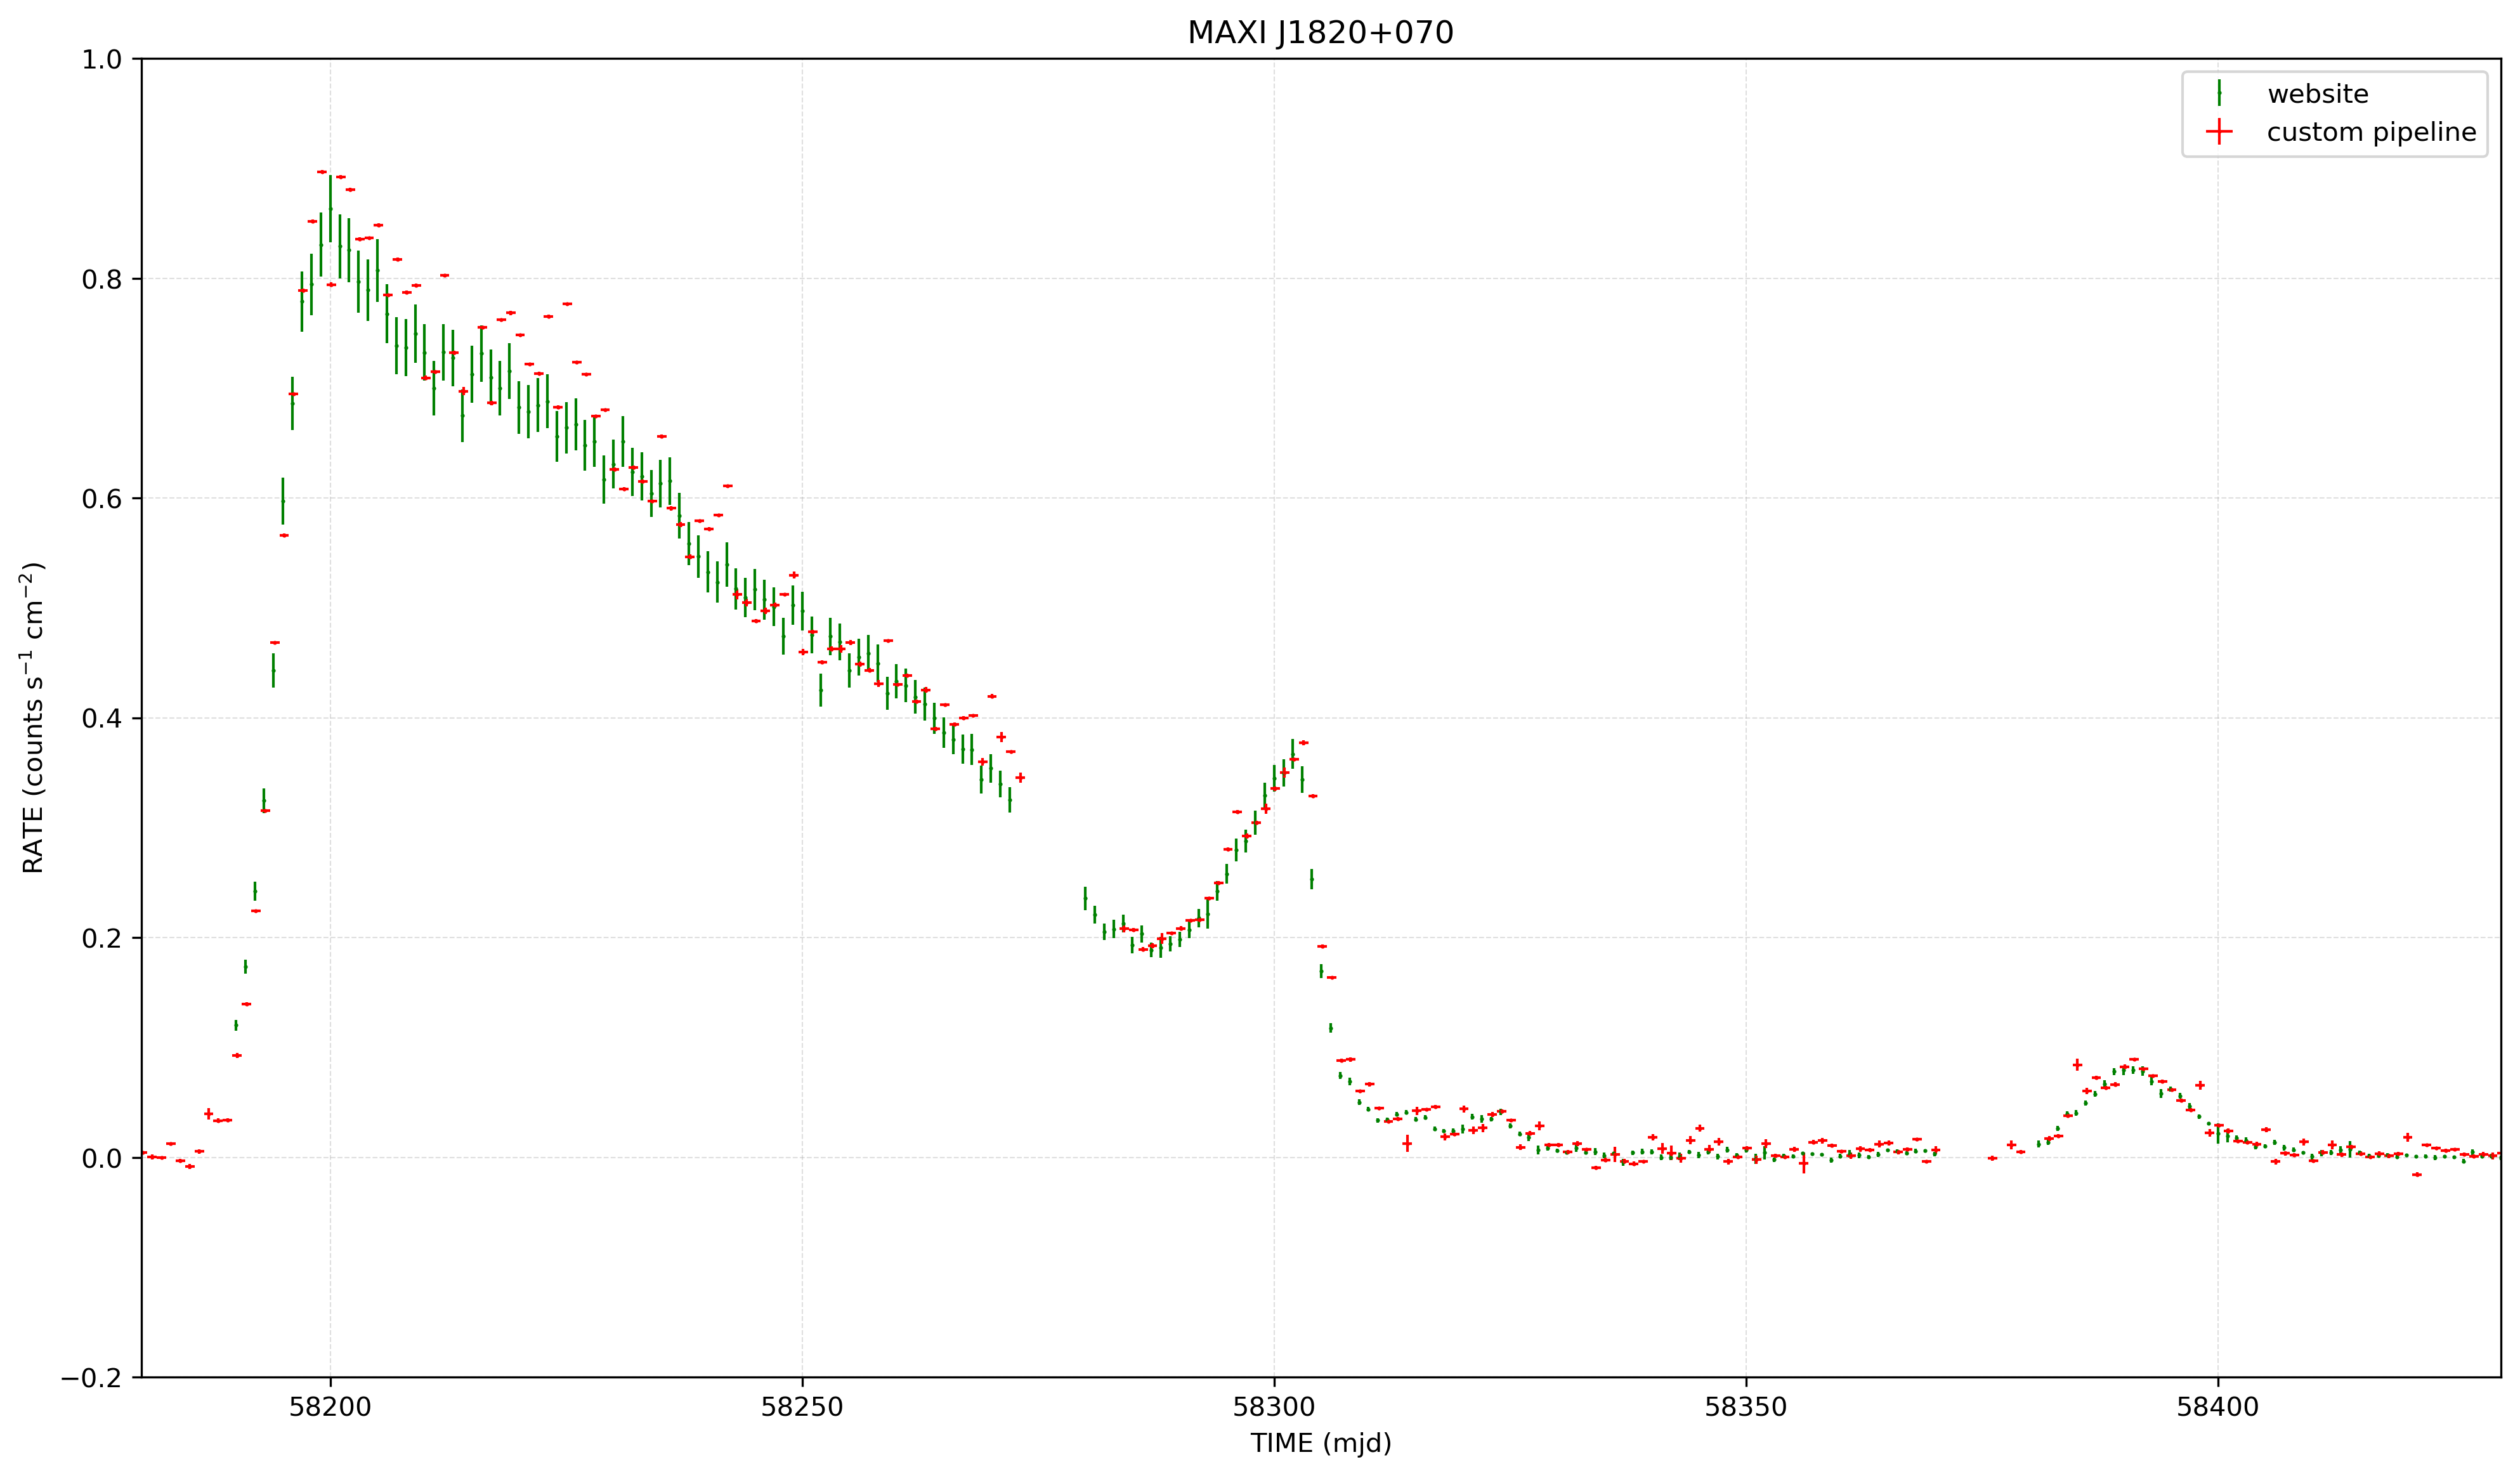

In [ ]:
plt.figure(figsize=(16, 9), dpi=300)

plt.errorbar(time2, rate2, err2, fmt=".", ms=1, elinewidth=1, color="green", label="website")
plt.errorbar(time1, rate1, yerr=err1, xerr=1/2, fmt=".", color='r', ms=1, elinewidth=1, label="custom pipeline")


plt.title("MAXI J1820+070")
plt.xlabel("TIME (mjd)")
plt.ylabel(r"RATE (counts s$^{-1}$ cm$^{-2}$)")
plt.legend()
plt.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.4)

# plt.xlim(58100, 58980)
plt.xlim(58180, 58430)
plt.ylim(-0.2, 1)

# ax = plt.gca()
# ax.xaxis.set_major_locator(MultipleLocator(30))

# plt.savefig("J1820_main.png", dpi=300)
plt.show()

In [11]:
print(time1[-1])
print(time1[0])

58972.12022957257
58101.12022957257
